# Proxmox edge-node health -- are the nuc-g hosts happy?

Reads the **actual host hardware values** off the four Proxmox edge nodes (`nuc-g2p-1/2`,
`nuc-g3p-1/2`) and judges whether each box is healthy. Each host runs an unprivileged **LXC**
with Alloy that bind-mounts the host and ships node/hwmon metrics to prod over OTLP
(`cluster="bond"`, `job="integrations/node_exporter"`; [docs/proxmox-monitoring.md](../docs/proxmox-monitoring.md)).

**What is genuine host data vs. what is the container's own view -- this matters here.**
node_exporter in the unprivileged LXC reads a *mix*: `/sys`-sourced signals (hwmon temps, NVMe,
cooling) and the host block layer (`node_disk_*` -- diskstats is not namespaced) are **genuine
host values**; but `/proc`-sourced CPU/memory/load are the **container cgroup view** -- memory is
the ~512 MiB LXC cgroup ([#544](https://github.com/symmatree/tiles/issues/544)), and
`node_cpu_seconds_total` exposes only the CT's single allotted core (verified: one `cpu` series).
So this notebook judges host health on the **host-reliable signals** (temperatures, throttle,
host disk I/O, host root filesystem) and treats CPU/memory/load as **CT liveness only, not host
load** (LXC memory/cgroup semantics are under separate active review).

Motivated by what actually makes an edge host unhappy (a hot day, a power event, a full disk):
- **Thermal**: CPU package/core overheating or thermal throttling; NVMe running hot.
- **Host storage**: the root LV (`pve-root`) filling; disk I/O saturation (the real host-stress signal).
- **Liveness after a power event**: all four came up and are shipping; uptime shows a shared reboot.

**"Is the edge even delivering?"** is one **assumptions gate** here, per node: a stale/missing
node is UNASSESSABLE, and for a Proxmox CT the likely cause is context-dependent -- the
`host_managed`/DHCP `eth0` trap on (re)deploy, or a cold power-event boot-race
([#684](https://github.com/symmatree/tiles/issues/684), resolved), else a generic CT/host-down.
**Proxmox host logs are a known gap** ([#686](https://github.com/symmatree/tiles/issues/686): the
hosts are journald-only but Alloy tails nonexistent `/var/log/*.log`), so there is deliberately no
log section -- silence there is not a finding.

**Thresholds are sourced.** CPU temp 90 C from the deployed **bond-mixin**
`BondProxmoxHighCoreTemperature`; NVMe vs its hardware-reported crit; disk-I/O and filesystem
thresholds from the deployed **node-exporter mixin** (`NodeDiskIOSaturation` 10,
`NodeFilesystemAlmostOutOfSpace` 5%/3% avail). Live `ALERTS` state is read as a cross-check.

Design: [tiles#653](https://github.com/symmatree/tiles/issues/653) (parent
[#644](https://github.com/symmatree/tiles/issues/644)), [docs/notebooks.md](../docs/notebooks.md),
sibling `metal-health.ipynb` and `raconteur-health.ipynb`.

Run from `notebooks/`: `jupyter nbconvert --to notebook --execute --inplace proxmox-health.ipynb`

In [1]:
mimir_url = "http://mimir-gateway.mimir.svc"   # edge node_exporter lands in Mimir (tiles tenant)
tenant = "tiles"                     # X-Scope-OrgID
cluster = "bond"                     # OTLP cluster attribute on the edge feed
instance_re = "nuc-g.*"              # node_exporter/instance selector for the edge hosts
expected_nodes = ["nuc-g2p-1", "nuc-g2p-2", "nuc-g3p-1", "nuc-g3p-2"]  # enumerate: a missing node is a finding
lookback_hours = 24
range_step_s = 300
metric_stale_s = 900       # chosen (no mixin): fixed-interval scrape; staler = CT not delivering, unassessable
instr_stale_s = 600        # chosen: Mimir-serving freshness gate
cpu_temp_warn_c = 90       # sourced: bond-mixin BondProxmoxHighCoreTemperature (avg platform_coretemp_0, 10m)
nvme_temp_warn_c = 70      # chosen: NVMe warn below the hardware crit (read live for headroom); only g3p expose NVMe hwmon
disk_io_sat_warn = 10      # sourced: node-exporter mixin NodeDiskIOSaturation (io_time_weighted rate, host block devices)
fs_full_warn_pct = 95      # sourced: NodeFilesystemAlmostOutOfSpace (avail < 5%)
fs_full_crit_pct = 97      # sourced: NodeFilesystemAlmostOutOfSpace critical (avail < 3%)
capture_file = ""          # replay a prior raw capture JSON instead of querying live
output_dir = ""            # if set: write raw capture + agent stats there
debug = False

In [2]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
from pathlib import Path
import nb_capture as nbc

plt.rcParams.update(nbc.MPL_STYLE)
NOTEBOOK = 'proxmox-health'
cap = nbc.Capture(replay_file=capture_file, mimir_url=mimir_url, tenant=tenant, cluster=cluster,
                  instance_re=instance_re, expected_nodes=expected_nodes, lookback_hours=lookback_hours,
                  range_step_s=range_step_s, metric_stale_s=metric_stale_s)
m = cap.meta
tenant, cluster, instance_re = m['tenant'], m['cluster'], m['instance_re']
expected_nodes = m['expected_nodes']
lookback_hours, step, metric_stale_s = m['lookback_hours'], m['range_step_s'], m['metric_stale_s']
mm = nbc.Mimir(cap, m['mimir_url'], tenant)
SEL = f'cluster="{cluster}", instance=~"{instance_re}"'


def byi(res):
    """{instance: value} from an instant vector keyed by the instance label."""
    return {r['metric'].get('instance', ''): float(r['value'][1]) for r in res}

print(f"mimir: {m['mimir_url']}  tenant: {tenant}  cluster: {cluster}  nodes: {expected_nodes}  "
      f"{'REPLAY of ' + cap.run_at if cap.replay else 'live'}")

mimir: http://mimir-gateway.mimir.svc  tenant: tiles  cluster: bond  nodes: ['nuc-g2p-1', 'nuc-g2p-2', 'nuc-g3p-1', 'nuc-g3p-2']  live


In [3]:
# --- ASSUMPTIONS: instruments before readings (the one data-through gate), per node ---
# Enumerate the four expected CTs; a stale/missing one is UNASSESSABLE. For a Proxmox CT the likely
# cause is context-dependent: the host_managed/DHCP eth0 trap on (re)deploy, a cold power-event
# boot-race (#684), else a generic CT/host-down -- check the box before assuming a trap.
mimir_ts = nbc.val(mm.q('instr: mimir up', 'max(timestamp(up))'))
mimir_age = cap.now - mimir_ts if not np.isnan(mimir_ts) else np.inf
node_ts = byi(mm.q('fresh: node_load1 by node', f'timestamp(node_load1{{{SEL}}})'))
node_age = {n: (cap.now - node_ts[n] if n in node_ts else np.inf) for n in expected_nodes}
present = [n for n in expected_nodes if node_age[n] <= metric_stale_s]
stale = [n for n in expected_nodes if n not in present]

print("=== ASSUMPTIONS (data-through gate) ===")
print(f"  mimir serving (up)   {'MISSING' if np.isinf(mimir_age) else f'{mimir_age:.0f}s old'}")
for n in expected_nodes:
    a = node_age[n]
    print(f"  {n:<10} node_exporter {'MISSING' if np.isinf(a) else f'{a:.0f}s old'}")
if np.isinf(mimir_age) or mimir_age > instr_stale_s:
    raise RuntimeError(f"unassessable: Mimir not serving fresh data ({mimir_age:.0f}s) -- see mimir-health.ipynb")
if not present:
    raise RuntimeError(f"unassessable: NONE of {expected_nodes} are delivering fresh metrics (all > "
                       f"{metric_stale_s}s). The whole edge feed is dark -- suspect the host_managed/DHCP eth0 "
                       f"trap or a power-event boot-race (#684, docs/proxmox-monitoring.md), or check the "
                       f"Proxmox hosts/CTs directly. This notebook reads host VALUES; it needs fresh data.")
for n in stale:
    print(f"  WARNING: {n} stale/missing (> {metric_stale_s}s) -- UNASSESSABLE below; check that CT (host_managed/DHCP #684)")
print("  NOTE: Proxmox host LOGS are a known gap (#686, journald-only) -- no log section; silence there is not a finding.")
inst = "|".join(present)
present_sel = f'cluster="{cluster}", instance=~"{inst}"'


=== ASSUMPTIONS (data-through gate) ===
  mimir serving (up)   1s old
  nuc-g2p-1  node_exporter 38s old
  nuc-g2p-2  node_exporter 9s old
  nuc-g3p-1  node_exporter 41s old
  nuc-g3p-2  node_exporter 17s old
  NOTE: Proxmox host LOGS are a known gap (#686, journald-only) -- no log section; silence there is not a finding.


In [4]:
# --- CAPTURE: the complete raw observation up front ---
S = present_sel

# Temperatures (host /sys, genuine). CPU: avg over platform_coretemp_0 matches the deployed alert;
# also keep max (hottest core). NVMe: only nuc-g3p-* expose an nvme hwmon chip.
cpu_temp_avg = byi(mm.q('cpu_temp_avg', f'avg by(instance)(node_hwmon_temp_celsius{{{S}, chip="platform_coretemp_0"}})'))
cpu_temp_max = byi(mm.q('cpu_temp_max', f'max by(instance)(node_hwmon_temp_celsius{{{S}, chip="platform_coretemp_0"}})'))
nvme_temp = byi(mm.q('nvme_temp', f'max by(instance)(node_hwmon_temp_celsius{{{S}, chip=~"nvme.*"}})'))
nvme_crit = byi(mm.q('nvme_crit', f'max by(instance)(node_hwmon_temp_crit_celsius{{{S}, chip=~"nvme.*"}})'))
# Throttle response: Processor / intel_powerclamp cooling devices only (NOT PCIe ASPM link-speed
# devices, which idle at a nonzero step and are unrelated to thermal throttling). cur==0 => no throttle.
cool_cur = byi(mm.q('cool_cur', f'max by(instance)(node_cooling_device_cur_state{{{S}, type=~"Processor|intel_powerclamp"}})'))

# Host storage: block-layer I/O saturation (genuine host devices) + host root LV fullness.
disk_io_sat = byi(mm.q('disk_io_sat', f'max by(instance)(rate(node_disk_io_time_weighted_seconds_total{{{S}}}[5m]))'))
# host root is the xfs pve-root LV; the CT's own root is a separate ext4 pve-vm--N disk (excluded).
fs_avail = mm.q('fs_avail', f'node_filesystem_avail_bytes{{{S}, mountpoint="/", fstype="xfs"}}')
fs_size = mm.q('fs_size', f'node_filesystem_size_bytes{{{S}, mountpoint="/", fstype="xfs"}}')
boot = byi(mm.q('boot', f'node_boot_time_seconds{{{S}}}'))

# CT-scoped (NOT host health): memory is the ~512 MiB cgroup (#544); node_cpu exposes one allotted
# core. Captured only to confirm CT liveness and make the caveat legible -- never turned into findings.
ct_mem_total = byi(mm.q('ct_mem_total', f'node_memory_MemTotal_bytes{{{S}}}'))
ct_mem_used_pct = byi(mm.q('ct_mem_used_pct', f'100 - (node_memory_MemAvailable_bytes{{{S}}} / node_memory_MemTotal_bytes{{{S}}} * 100)'))
ct_cores = byi(mm.q('ct_cores', f'count by(instance)(count by(instance,cpu)(node_cpu_seconds_total{{{S}, mode="idle"}}))'))
host_cores = byi(mm.q('host_cores', f'count by(instance)(node_cpu_scaling_frequency_hertz{{{S}}})'))  # host cores visible via /sys

# Live alert state (cross-check; empty = nothing firing/pending on these hosts)
alerts = mm.q('alerts', 'ALERTS{alertname=~"BondProxmox.*|NodeFilesystem.*|NodeDiskIOSaturation", alertstate=~"firing|pending"}')

# Trends (host-reliable)
f_cputemp = nbc.frame(mm.qr('cputemp_trend', f'avg by(instance)(node_hwmon_temp_celsius{{{S}, chip="platform_coretemp_0"}})', lookback_hours, step), 'instance')
f_iosat = nbc.frame(mm.qr('iosat_trend', f'max by(instance)(rate(node_disk_io_time_weighted_seconds_total{{{S}}}[5m]))', lookback_hours, step), 'instance')
print(f"captured {len(cap.data['calls'])} raw calls; assessable nodes: {present}; "
      f"NVMe hwmon on: {sorted(nvme_temp)}")

captured 18 raw calls; assessable nodes: ['nuc-g2p-1', 'nuc-g2p-2', 'nuc-g3p-1', 'nuc-g3p-2']; NVMe hwmon on: ['nuc-g3p-1', 'nuc-g3p-2']


In [5]:
# --- PER-NODE HEALTH TABLE (the deliverable: one row per host, judged on host-reliable signals) ---
def g(d, n):
    v = d.get(n)
    return float('nan') if v is None else v

av = byi(fs_avail); sz = byi(fs_size)
root_full = {n: 100 * (1 - av[n] / sz[n]) for n in sz if sz.get(n)}
rows = []
for n in expected_nodes:
    if n not in present:
        rows.append({'node': n, 'state': 'UNASSESSABLE (stale/missing)'}); continue
    rows.append({
        'node': n, 'state': 'shipping',
        'up_d': (cap.now - boot[n]) / 86400 if n in boot else float('nan'),
        'coreAvgC': g(cpu_temp_avg, n), 'coreMaxC': g(cpu_temp_max, n),
        'nvmeC': g(nvme_temp, n), 'throttle': int(g(cool_cur, n)) if not np.isnan(g(cool_cur, n)) else 0,
        'ioSat': g(disk_io_sat, n), 'rootFS%': g(root_full, n),
        'hostCore': int(g(host_cores, n)) if not np.isnan(g(host_cores, n)) else None,
        'ctMemGi': g(ct_mem_total, n) / 2**30 if n in ct_mem_total else float('nan'),
    })
tbl = pd.DataFrame(rows)
print(tbl.to_string(index=False, na_rep='-', float_format=lambda v: f'{v:.1f}'))
print("\ncoreAvgC = avg platform_coretemp (matches the deployed alert)  coreMaxC = hottest core  "
      "nvmeC = NVMe (g3p only)  throttle = cooling cur_state (0=none)  ioSat = host weighted disk-io rate  "
      "rootFS% = pve-root LV full  hostCore = host cores seen via /sys")
print("ctMemGi = the ~0.5 GiB LXC cgroup (NOT host RAM, #544) -- shown for CT liveness, deliberately not judged.")

     node    state  up_d  coreAvgC  coreMaxC  nvmeC  throttle  ioSat  rootFS%  hostCore  ctMemGi
nuc-g2p-1 shipping  23.1      78.0      78.0      -         0    0.0     43.9         4      0.5
nuc-g2p-2 shipping  23.1      67.0      67.0      -         0    0.1     40.2         4      0.5
nuc-g3p-1 shipping  23.1      80.0      80.0   46.9         0    0.1     40.2         4      0.5
nuc-g3p-2 shipping  23.1      67.0      67.0   45.9         0    0.0     40.2         4      0.5

coreAvgC = avg platform_coretemp (matches the deployed alert)  coreMaxC = hottest core  nvmeC = NVMe (g3p only)  throttle = cooling cur_state (0=none)  ioSat = host weighted disk-io rate  rootFS% = pve-root LV full  hostCore = host cores seen via /sys
ctMemGi = the ~0.5 GiB LXC cgroup (NOT host RAM, #544) -- shown for CT liveness, deliberately not judged.


nuc-g2p-1: CPU avg 78C / max 78C (warn 90C)  NVMe hwmon n/a
nuc-g2p-2: CPU avg 67C / max 67C (warn 90C)  NVMe hwmon n/a
nuc-g3p-1: CPU avg 80C / max 80C (warn 90C)  NVMe 47C (warn 70, hw crit 95C)
nuc-g3p-2: CPU avg 67C / max 67C (warn 90C)  NVMe 46C (warn 70, hw crit 95C)


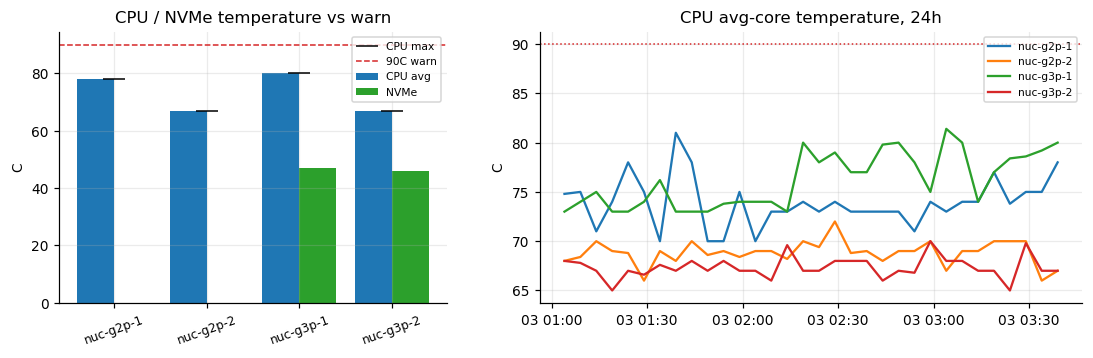

In [6]:
# --- THERMAL: CPU package/cores vs the deployed 90 C alert; NVMe vs its hardware crit ---
# All cool today is the expected baseline. This section earns its keep on a hot day and as the
# before/after around a power event -- read the deployed BondProxmoxHighCoreTemperature state, don't
# reinvent the threshold.
for n in present:
    ns = f"  NVMe {nvme_temp[n]:.0f}C (warn {nvme_temp_warn_c}, hw crit {nvme_crit.get(n, float('nan')):.0f}C)" if n in nvme_temp else "  NVMe hwmon n/a"
    print(f"{n}: CPU avg {cpu_temp_avg.get(n, float('nan')):.0f}C / max {cpu_temp_max.get(n, float('nan')):.0f}C (warn {cpu_temp_warn_c}C){ns}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.2), width_ratios=[1, 1.4])
ax = axes[0]
x = np.arange(len(present))
ax.bar(x - 0.2, [cpu_temp_avg.get(n, np.nan) for n in present], 0.4, label='CPU avg', color='C0')
ax.bar(x + 0.2, [nvme_temp.get(n, np.nan) for n in present], 0.4, label='NVMe', color='C2')
ax.plot(x, [cpu_temp_max.get(n, np.nan) for n in present], 'k_', ms=14, label='CPU max')
ax.axhline(cpu_temp_warn_c, color='C3', ls='--', lw=1, label=f'{cpu_temp_warn_c}C warn')
ax.set_xticks(x); ax.set_xticklabels(present, fontsize=8, rotation=20)
ax.set_ylabel('C'); ax.set_title('CPU / NVMe temperature vs warn'); ax.legend(fontsize=7)
ax = axes[1]
for n in f_cputemp.columns:
    ax.plot(f_cputemp.index, f_cputemp[n], lw=1.5, label=n)
ax.axhline(cpu_temp_warn_c, color='C3', ls=':', lw=1)
ax.set_ylabel('C'); ax.set_title(f'CPU avg-core temperature, {lookback_hours}h'); ax.legend(fontsize=7)
nbc.show(fig)

host disk I/O saturation (io_time_weighted rate; NodeDiskIOSaturation warn = 10):
  nuc-g2p-1  ioSat 0.05
  nuc-g2p-2  ioSat 0.06
  nuc-g3p-1  ioSat 0.12
  nuc-g3p-2  ioSat 0.01

host root LV (pve-root) fullness:
  nuc-g2p-1   43.9% full (17.9GiB free of 32GiB)
  nuc-g2p-2   40.2% full (19.1GiB free of 32GiB)
  nuc-g3p-1   40.2% full (19.1GiB free of 32GiB)
  nuc-g3p-2   40.2% full (19.1GiB free of 32GiB)


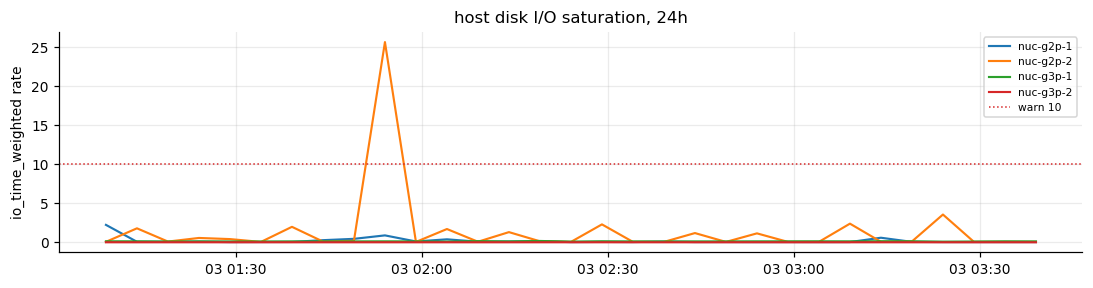

In [7]:
# --- HOST STORAGE & I/O: block-layer saturation (the real host-stress signal) + root LV fullness ---
# node_disk_* reads the HOST diskstats (not namespaced), so this is genuine host I/O -- the issue's
# preferred host-stress signal since CPU/mem here are the CT cgroup view. VM/thin-pool storage is
# not a mounted filesystem, so only the pve-root LV fullness is visible via node_exporter.
print("host disk I/O saturation (io_time_weighted rate; NodeDiskIOSaturation warn = {}):".format(disk_io_sat_warn))
for n in present:
    flag = '  <-- >= warn' if disk_io_sat.get(n, 0) >= disk_io_sat_warn else ''
    print(f"  {n:<10} ioSat {disk_io_sat.get(n, float('nan')):.2f}{flag}")
print("\nhost root LV (pve-root) fullness:")
for n in present:
    if n in root_full:
        print(f"  {n:<10} {root_full[n]:5.1f}% full ({av[n]/2**30:.1f}GiB free of {sz[n]/2**30:.0f}GiB)")

fig, ax = plt.subplots(figsize=(12, 2.6))
for n in f_iosat.columns:
    ax.plot(f_iosat.index, f_iosat[n], lw=1.4, label=n)
ax.axhline(disk_io_sat_warn, color='C3', ls=':', lw=1, label=f'warn {disk_io_sat_warn}')
ax.set_ylabel('io_time_weighted rate'); ax.set_title(f'host disk I/O saturation, {lookback_hours}h'); ax.legend(fontsize=7)
nbc.show(fig)

In [8]:
# --- SUMMARY: assumptions ledger first, then findings vs the sourced thresholds ---
# Findings come ONLY from host-reliable signals. CPU/memory/load are the CT cgroup view (#544) and
# are deliberately never turned into host findings.
findings = []
if stale:
    findings.append(f"UNASSESSABLE: {stale} stale/missing (> {metric_stale_s}s) -- check the CT (host_managed/DHCP #684)")
for n in present:
    if n in cpu_temp_avg and cpu_temp_avg[n] >= cpu_temp_warn_c:
        findings.append(f"{n}: CPU avg {cpu_temp_avg[n]:.0f}C >= {cpu_temp_warn_c}C (BondProxmoxHighCoreTemperature)")
    if n in nvme_temp and n in nvme_crit and nvme_temp[n] >= nvme_crit[n] - 5:
        findings.append(f"{n}: NVMe {nvme_temp[n]:.0f}C near hw crit {nvme_crit[n]:.0f}C")
    elif n in nvme_temp and nvme_temp[n] >= nvme_temp_warn_c:
        findings.append(f"{n}: NVMe {nvme_temp[n]:.0f}C >= {nvme_temp_warn_c}C (chosen warn)")
    if cool_cur.get(n, 0) > 0:
        findings.append(f"{n}: thermal throttle active (cooling cur_state {cool_cur[n]:.0f})")
    if n in disk_io_sat and disk_io_sat[n] >= disk_io_sat_warn:
        findings.append(f"{n}: host disk io-sat {disk_io_sat[n]:.1f} >= {disk_io_sat_warn} (NodeDiskIOSaturation)")
    if n in root_full and root_full[n] >= fs_full_crit_pct:
        findings.append(f"{n}: pve-root {root_full[n]:.0f}% full >= {fs_full_crit_pct}% CRITICAL (NodeFilesystemAlmostOutOfSpace)")
    elif n in root_full and root_full[n] >= fs_full_warn_pct:
        findings.append(f"{n}: pve-root {root_full[n]:.0f}% full >= {fs_full_warn_pct}% (NodeFilesystemAlmostOutOfSpace)")

firing = [(r['metric'].get('alertname',''), r['metric'].get('instance',''), r['metric'].get('alertstate','')) for r in alerts]
boots = sorted(set(round(boot[n]) for n in present if n in boot))
shared_boot = len(boots) <= 1 or (max(boots) - min(boots) < 300)  # all within 5 min = a shared power event

print("=" * 66)
print("PROXMOX EDGE-NODE HEALTH SUMMARY")
print("=" * 66)
print(f"run:    {cap.run_at}  ({cap.mode})")
print(f"nodes:  assessable {present}" + (f"; UNASSESSABLE {stale}" if stale else ""))
print(f"data:   mimir {mimir_age:.0f}s; " + ", ".join(f"{n} {node_age[n]:.0f}s" for n in expected_nodes) + f"  (gate < {metric_stale_s}s)")
print(f"alerts: {firing if firing else 'none firing/pending on nuc-g*'}")
if present:
    ud = [(cap.now - boot[n]) / 86400 for n in present if n in boot]
    print(f"uptime: {min(ud):.1f}-{max(ud):.1f}d" + ("  (all booted together -- a shared power event)" if shared_boot and len(present) > 1 else ""))
print()
if findings:
    print(f"Findings ({len(findings)}):")
    for fn in findings:
        print(f"  ! {fn}")
else:
    print("Findings: none -- all assessable hosts shipping, CPU/NVMe temps below thresholds, no "
          "throttle, host disk I/O and root filesystem nominal.")
print()
for n in present:
    print(f"  {n}: up {(cap.now - boot.get(n, cap.now)) / 86400:.1f}d  CPU {cpu_temp_avg.get(n, float('nan')):.0f}C avg/"
          f"{cpu_temp_max.get(n, float('nan')):.0f}C max" + (f"  NVMe {nvme_temp[n]:.0f}C" if n in nvme_temp else "")
          + f"  ioSat {disk_io_sat.get(n, float('nan')):.1f}  root {root_full.get(n, float('nan')):.0f}%")
print("\n(CPU/memory/load are the CT cgroup view, not host -- #544; not judged here.)")

PROXMOX EDGE-NODE HEALTH SUMMARY
run:    2026-08-03T03:39:00.098997+00:00  (live)
nodes:  assessable ['nuc-g2p-1', 'nuc-g2p-2', 'nuc-g3p-1', 'nuc-g3p-2']
data:   mimir 1s; nuc-g2p-1 38s, nuc-g2p-2 9s, nuc-g3p-1 41s, nuc-g3p-2 17s  (gate < 900s)
alerts: [('NodeDiskIOSaturation', 'raconteur', 'pending')]
uptime: 23.1-23.1d  (all booted together -- a shared power event)

Findings: none -- all assessable hosts shipping, CPU/NVMe temps below thresholds, no throttle, host disk I/O and root filesystem nominal.

  nuc-g2p-1: up 23.1d  CPU 78C avg/78C max  ioSat 0.0  root 44%
  nuc-g2p-2: up 23.1d  CPU 67C avg/67C max  ioSat 0.1  root 40%
  nuc-g3p-1: up 23.1d  CPU 80C avg/80C max  NVMe 47C  ioSat 0.1  root 40%
  nuc-g3p-2: up 23.1d  CPU 67C avg/67C max  NVMe 46C  ioSat 0.0  root 40%

(CPU/memory/load are the CT cgroup view, not host -- #544; not judged here.)


In [9]:
# --- AGENT-READABLE STATS -- consolidated JSON, assumptions leading ---
def _n(v):
    return None if v is None or (isinstance(v, float) and not np.isfinite(v)) else round(float(v), 4)

agent_stats = {
    'notebook': f'{NOTEBOOK}.ipynb', 'run_at': cap.run_at, 'mode': cap.mode,
    'assumptions': {'status': 'ok' if not stale else 'degraded',
                    'mimir_age_s': _n(mimir_age), 'node_age_s': {n: _n(node_age[n]) for n in expected_nodes},
                    'assessable': present, 'unassessable': stale,
                    'proxmox_host_logs': 'known-gap (#686)'},
    'findings': findings,
    'alerts_active': [{'alert': a, 'instance': i, 'state': s} for a, i, s in firing],
    'nodes': {n: {
        'uptime_days': _n((cap.now - boot[n]) / 86400) if n in boot else None,
        'cpu_temp_avg_c': _n(cpu_temp_avg.get(n)), 'cpu_temp_max_c': _n(cpu_temp_max.get(n)),
        'nvme_temp_c': _n(nvme_temp.get(n)), 'nvme_crit_c': _n(nvme_crit.get(n)),
        'throttle_cur_state': _n(cool_cur.get(n)),
        'disk_io_sat': _n(disk_io_sat.get(n)), 'root_fs_pct_full': _n(root_full.get(n)),
        'host_cores': _n(host_cores.get(n)),
        # CT-scoped, not host -- explicitly labelled so a consumer never reads these as host load.
        'ct_cgroup_mem_gib': _n(ct_mem_total.get(n, 0) / 2**30), 'ct_cgroup_mem_used_pct': _n(ct_mem_used_pct.get(n)),
        'ct_visible_cores': _n(ct_cores.get(n)),
    } for n in present},
    'caveat': 'CPU/memory/load are the LXC cgroup view (#544), not host; host health judged on '
              'temps, throttle, host disk I/O, root filesystem.',
}
print(json.dumps(agent_stats, indent=1))

if output_dir:
    out = Path(output_dir); out.mkdir(parents=True, exist_ok=True)
    cap.save(out / f'{NOTEBOOK}.capture.json')
    (out / f'{NOTEBOOK}.stats.json').write_text(json.dumps(agent_stats, indent=2))
    print(f"wrote {out / f'{NOTEBOOK}.capture.json'} and {out / f'{NOTEBOOK}.stats.json'}")

{
 "notebook": "proxmox-health.ipynb",
 "run_at": "2026-08-03T03:39:00.098997+00:00",
 "mode": "live",
 "assumptions": {
  "status": "ok",
  "mimir_age_s": 0.943,
  "node_age_s": {
   "nuc-g2p-1": 37.628,
   "nuc-g2p-2": 8.794,
   "nuc-g3p-1": 41.318,
   "nuc-g3p-2": 17.401
  },
  "assessable": [
   "nuc-g2p-1",
   "nuc-g2p-2",
   "nuc-g3p-1",
   "nuc-g3p-2"
  ],
  "unassessable": [],
  "proxmox_host_logs": "known-gap (#686)"
 },
 "findings": [],
 "alerts_active": [
  {
   "alert": "NodeDiskIOSaturation",
   "instance": "raconteur",
   "state": "pending"
  }
 ],
 "nodes": {
  "nuc-g2p-1": {
   "uptime_days": 23.0897,
   "cpu_temp_avg_c": 78.0,
   "cpu_temp_max_c": 78.0,
   "nvme_temp_c": null,
   "nvme_crit_c": null,
   "throttle_cur_state": 0.0,
   "disk_io_sat": 0.0475,
   "root_fs_pct_full": 43.8747,
   "host_cores": 4.0,
   "ct_cgroup_mem_gib": 0.5,
   "ct_cgroup_mem_used_pct": 10.3708,
   "ct_visible_cores": 1.0
  },
  "nuc-g2p-2": {
   "uptime_days": 23.0897,
   "cpu_temp_avg_c":